<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/salsabil/canteen_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
!pip install catboost

In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [71]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/main/data/canteen_dataset_feature_engineered.csv"

df = pd.read_csv(url)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,1.50,3.0,4.50,30,7,False,49,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,3.69,2.0,7.38,15,6,True,4,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,1.54,1.5,2.31,29,7,False,48,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.81,1.5,2.71,17,7,False,36,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,4.69,2.0,9.38,3,7,False,22,True,False,True,...,True,False,False,False,True,False,False,False,False,False


In [72]:
df.shape

(2600, 24)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int64  
 4   Month                     2600 non-null   int64  
 5   Weekend                   2600 non-null   bool   
 6   Day_Number                2600 non-null   int64  
 7   Meal_Dinner               2600 non-null   bool   
 8   Meal_Lunch                2600 non-null   bool   
 9   Food_Category_Rice        2600 non-null   bool   
 10  Food_Category_Soup        2600 non-null   bool   
 11  Food_Category_Vegetables  2600 non-null   bool   
 12  Canteen_Section_B         2600 non-null   bool   
 13  Canteen_Section_C         2600 non-null   bool   
 14  Canteen_

In [106]:
# ================================
# STEP 5 : Statistical Summary
# ================================

display(df.describe())

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Day_Number,Log_Unit_Price,Weekend_Unit_Price
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,2.585988,3.634808,9.233154,15.831154,6.824615,29.729231,1.401895,1.081154
std,1.408281,2.585178,8.952404,8.813420,0.681200,17.640257,0.490008,2.186555
min,0.100000,1.500000,0.150000,1.000000,6.000000,0.000000,0.916291,0.000000
25%,1.390000,2.000000,3.495000,8.000000,6.000000,14.000000,1.098612,0.000000
50%,2.600000,3.000000,6.360000,16.000000,7.000000,30.000000,1.386294,0.000000
75%,3.800000,8.000000,10.950000,23.000000,7.000000,45.000000,2.197225,1.500000
max,5.000000,8.000000,40.000000,31.000000,8.000000,60.000000,2.197225,8.000000


In [105]:
missing = df.isnull().sum()

display(missing)

print("Total Missing Values:", missing.sum())

,0
Waste_Weight_kg,0
Unit_Price_per_kg,0
Cost_Loss,0
Day,0
Month,0
Weekend,0
Day_Number,0
Meal_Dinner,0
Meal_Lunch,0
Food_Category_Rice,0


Total Missing Values: 0


In [107]:
# ================================
# STEP 7 : Duplicate Rows
# ================================

duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 0


#### Distribution of the raw continuous target

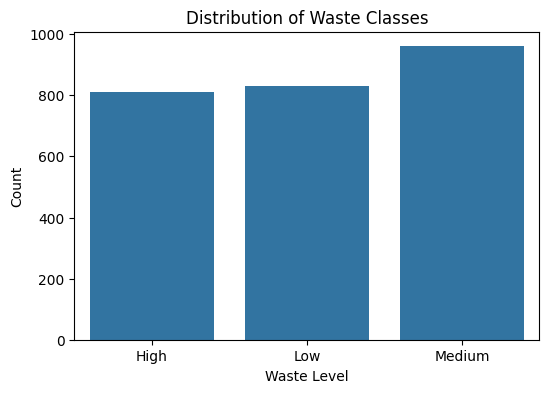

In [74]:
class_counts = (
    df["Waste_Weight_kg"]
      .apply(classify_waste_temp)
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Distribution of Waste Classes")
plt.xlabel("Waste Level")
plt.ylabel("Count")

plt.show()

###barcharts of the raw target against your categorical features

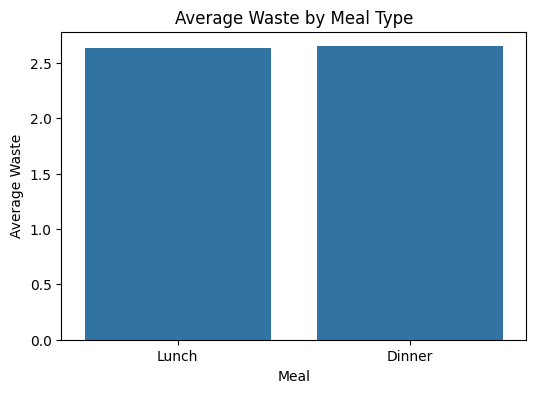

In [75]:
meal_avg = pd.DataFrame({
    "Meal": ["Lunch", "Dinner"],
    "Average Waste": [
        df[df["Meal_Lunch"]]["Waste_Weight_kg"].mean(),
        df[df["Meal_Dinner"]]["Waste_Weight_kg"].mean()
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=meal_avg,
    x="Meal",
    y="Average Waste"
)

plt.title("Average Waste by Meal Type")
plt.show()

### Average waste by Food category

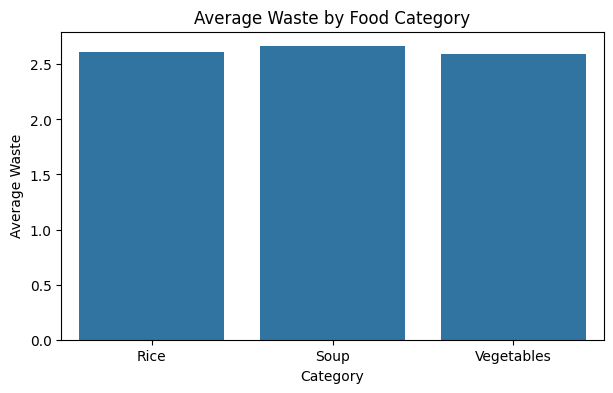

In [76]:
food_avg = pd.DataFrame({
    "Category": ["Rice","Soup","Vegetables"],
    "Average Waste":[
        df[df["Food_Category_Rice"]]["Waste_Weight_kg"].mean(),
        df[df["Food_Category_Soup"]]["Waste_Weight_kg"].mean(),
        df[df["Food_Category_Vegetables"]]["Waste_Weight_kg"].mean()
    ]
})

plt.figure(figsize=(7,4))

sns.barplot(
    data=food_avg,
    x="Category",
    y="Average Waste"
)

plt.title("Average Waste by Food Category")

plt.show()

###Canteen sections

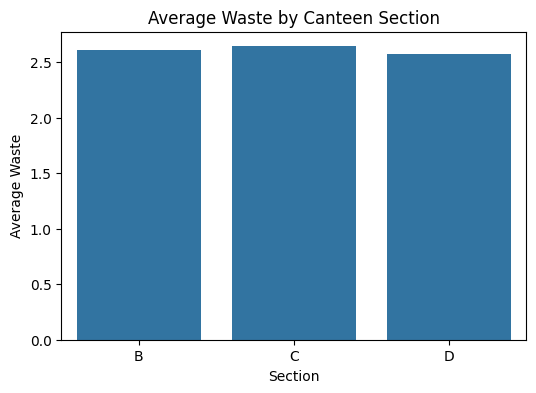

In [77]:
section_avg = pd.DataFrame({
    "Section":["B","C","D"],
    "Average Waste":[
        df[df["Canteen_Section_B"]]["Waste_Weight_kg"].mean(),
        df[df["Canteen_Section_C"]]["Waste_Weight_kg"].mean(),
        df[df["Canteen_Section_D"]]["Waste_Weight_kg"].mean()
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=section_avg,
    x="Section",
    y="Average Waste"
)

plt.title("Average Waste by Canteen Section")

plt.show()

###correlation of numeric features with the raw target

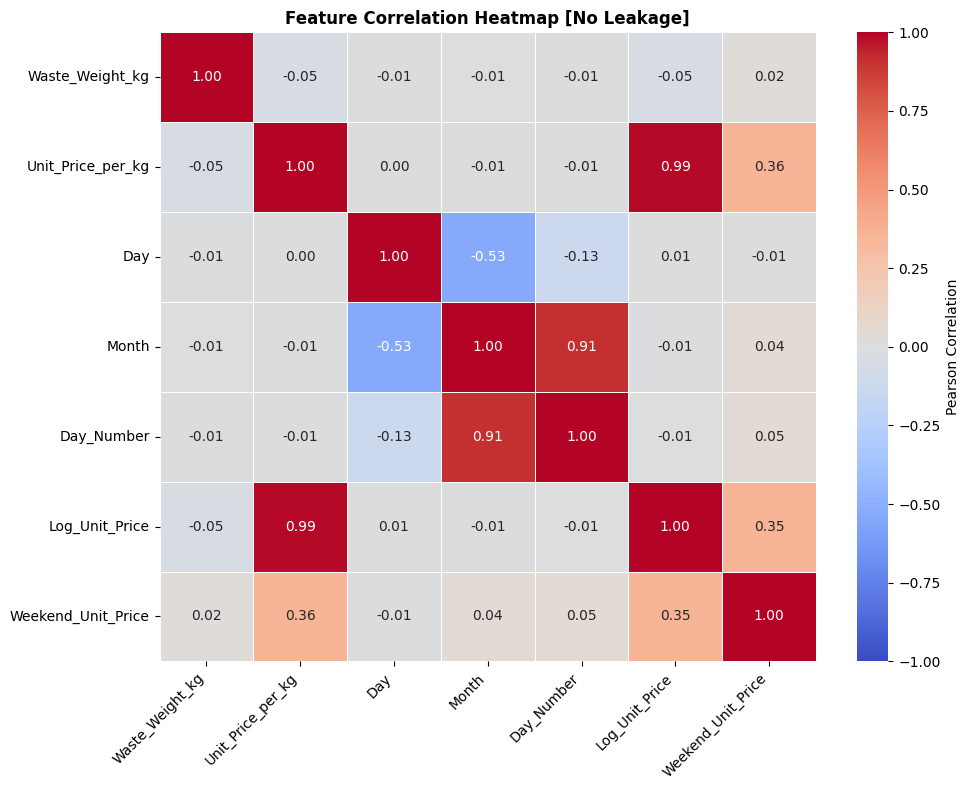

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32', 'int8']).columns

# 2. Exclude target/leakage variables (except the target we want to plot against)
leakage_cols = ["Cost_Loss"]
feature_cols = [col for col in numeric_cols if col not in leakage_cols]

# 3. Compute correlation matrix
corr_matrix = df[feature_cols].corr()

# 4. Plot Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Displays correlation numbers inside cells
    fmt=".2f",           # Rounds numbers to 2 decimal places
    cmap="coolwarm",     # Red = Positive correlation, Blue = Negative correlation
    vmin=-1, vmax=1,     # Sets bounds for standard Pearson scale
    center=0,            # Keeps 0 as neutral white/light grey
    linewidths=0.5,      # Adds subtle grid lines between squares
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Feature Correlation Heatmap [No Leakage]", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

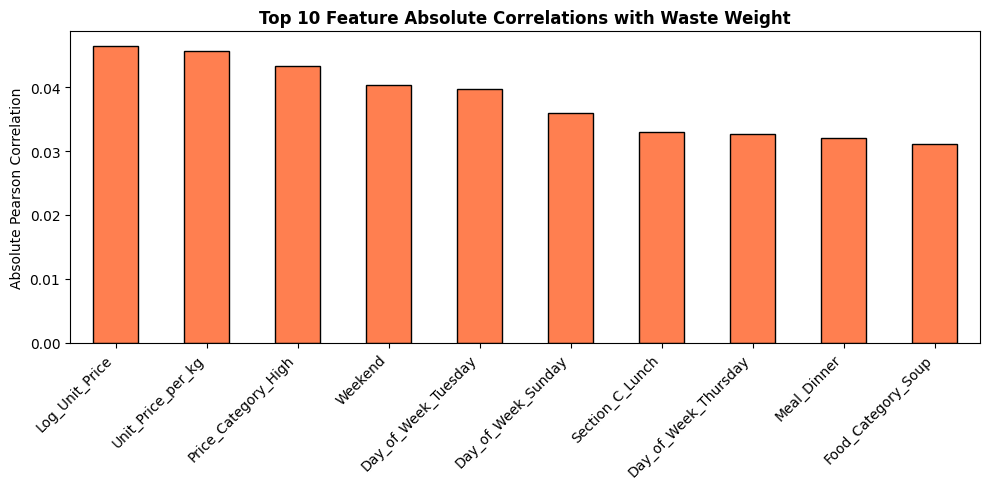

In [109]:
import matplotlib.pyplot as plt

# 1. Safely drop non-feature/target columns without crashing if one is missing
df_corr = df.drop(columns=["Waste_Level", "Cost_Loss"], errors="ignore").copy()

# 2. Convert booleans to integers temporarily for correlation computation
for col in df_corr.select_dtypes(include=['bool']).columns:
    df_corr[col] = df_corr[col].astype(int)

# 3. Calculate correlations against Waste_Weight_kg
corr_all = df_corr.corr()["Waste_Weight_kg"].drop("Waste_Weight_kg", errors="ignore")

# 4. Plot the top 10 features by absolute correlation
plt.figure(figsize=(10, 5))
corr_all.abs().sort_values(ascending=False).head(10).plot(kind="bar", color="coral", edgecolor="black")

plt.title("Top 10 Feature Absolute Correlations with Waste Weight", fontsize=12, fontweight="bold")
plt.ylabel("Absolute Pearson Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

###Average Waste by Month

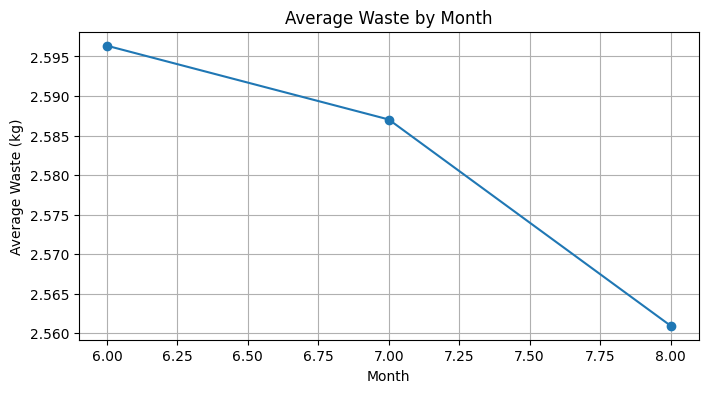

In [110]:
monthly_avg = df.groupby("Month")["Waste_Weight_kg"].mean()

plt.figure(figsize=(8,4))

monthly_avg.plot(marker="o")

plt.title("Average Waste by Month")
plt.ylabel("Average Waste (kg)")
plt.xlabel("Month")

plt.grid(True)

plt.show()

###Average Waste by Day of Month

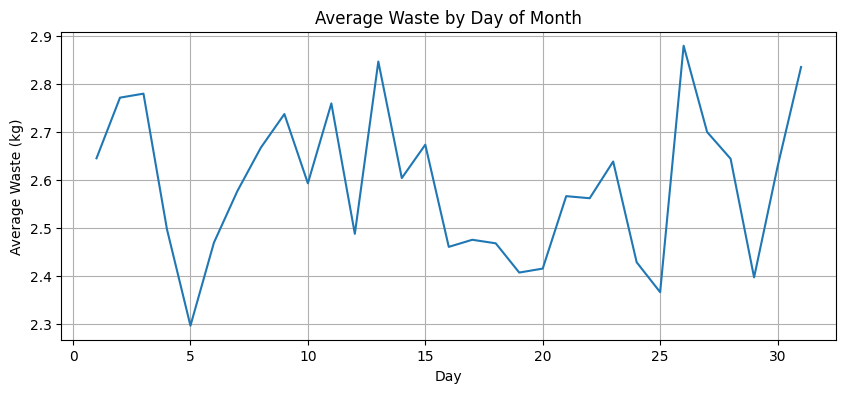

In [111]:
daily_avg = df.groupby("Day")["Waste_Weight_kg"].mean()

plt.figure(figsize=(10,4))

daily_avg.plot()

plt.title("Average Waste by Day of Month")
plt.ylabel("Average Waste (kg)")
plt.xlabel("Day")

plt.grid(True)

plt.show()

### Compare current class sizes vs. what quantile-based (equal-size) bins would look like

In [112]:
q33, q66 = df["Waste_Weight_kg"].quantile([0.33, 0.66])
print(f"Quantile-based cutoffs would be: {q33:.2f} (Low/Medium), {q66:.2f} (Medium/High)")
print(f"Your current cutoffs are: 1.7 (Low/Medium), 3.5 (Medium/High)")

# Apply YOUR existing cutoffs manually here (since classify_waste() hasn't been defined yet)
def classify_waste_temp(weight):
    if weight <= 1.7:
        return "Low"
    elif weight <= 3.5:
        return "Medium"
    else:
        return "High"

df["Waste_Level_Current"] = df["Waste_Weight_kg"].apply(classify_waste_temp)
df["Waste_Level_Quantile"] = pd.qcut(
    df["Waste_Weight_kg"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nYour current bin sizes:")
print(df["Waste_Level_Current"].value_counts())
print("\nQuantile-based bin sizes:")
print(df["Waste_Level_Quantile"].value_counts())

# Clean up temp columns so they don't interfere later
df.drop(columns=["Waste_Level_Current", "Waste_Level_Quantile"], inplace=True)

Quantile-based cutoffs would be: 1.76 (Low/Medium), 3.39 (Medium/High)
Your current cutoffs are: 1.7 (Low/Medium), 3.5 (Medium/High)

Your current bin sizes:
Waste_Level_Current
Medium    960
Low       829
High      811
Name: count, dtype: int64

Quantile-based bin sizes:
Waste_Level_Quantile
Medium    872
Low       869
High      859
Name: count, dtype: int64


##Creating classification target

In [113]:
def classify_waste(weight):
    if weight <= 1.7:
        return "Low"
    elif weight <= 3.5:
        return "Medium"
    else:
        return "High"

df["Waste_Level"] = df["Waste_Weight_kg"].apply(classify_waste)

In [114]:
df["Waste_Level"].value_counts()

,count
Waste_Level,
Medium,960
Low,829
High,811


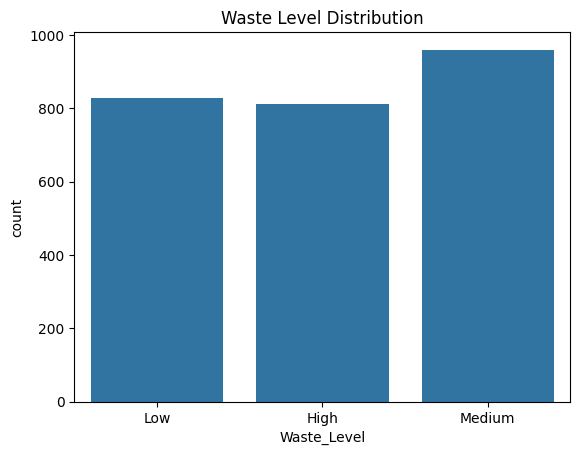

In [115]:
sns.countplot(
    data=df,
    x="Waste_Level"
)

plt.title("Waste Level Distribution")
plt.show()

##Separating Features and Target

In [116]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Waste_Level"
    ]
)

y = df["Waste_Level"]

print(X.shape)
print(y.shape)

(2600, 27)
(2600,)


In [117]:
X = X.astype(int)
X.head()

,Unit_Price_per_kg,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,...,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High,Log_Unit_Price,High_Price_Dinner,Weekend_Unit_Price,Section_C_Lunch,Soup_Dinner
0,3,30,7,0,49,1,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
1,2,15,6,1,4,0,0,1,0,0,...,0,0,0,0,0,1,0,2,0,0
2,1,29,7,0,48,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,17,7,0,36,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2,3,7,0,22,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


##Encoding Target Labels

In [118]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

['High' 'Low' 'Medium']


###Feature Engineering

In [119]:
import numpy as np

# --- FEATURE ENGINEERING ---
# 1. Non-linear price transformation
df['Log_Unit_Price'] = np.log1p(df['Unit_Price_per_kg'])

# 2. Context Interaction Features
df['High_Price_Dinner'] = df['Price_Category_High'] * df['Meal_Dinner']
df['Weekend_Unit_Price'] = df['Weekend'] * df['Unit_Price_per_kg']

# 3. Domain Groupings (Section & Meal Interactions)
df['Section_C_Lunch'] = df['Canteen_Section_C'] * df['Meal_Lunch']
df['Soup_Dinner'] = df['Food_Category_Soup'] * df['Meal_Dinner']

##Separate Features & Train/Test Split

In [120]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. RE-CREATE TARGET VARIABLE (Safe against double-mapping NaNs) ---
# Bin continuous Waste_Weight_kg directly into 3 categorical strings
df["Waste_Level"] = pd.qcut(
    df["Waste_Weight_kg"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# --- 2. FEATURE MATRIX (X) AND TARGET VECTOR (y) ---
# Drop target and leakage columns
X = df.drop(columns=["Waste_Weight_kg", "Cost_Loss", "Waste_Level"], errors="ignore")
y = df["Waste_Level"]

# --- 3. CLEAN MISSING VALUES & DATA TYPES ---
# Fill any NaNs in feature matrix with 0
X = X.fillna(0)

# Convert boolean columns to integers (0/1)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# --- 4. TRAIN / TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 5. VERIFY SHAPES ---
print("✅ Pipeline executed successfully!")
print(f"X_train shape: {X_train.shape}")  # Expecting (2080, N)
print(f"X_test shape:  {X_test.shape}")   # Expecting (520, N)
print(f"y_train class distribution:\n{y_train.value_counts()}")

✅ Pipeline executed successfully!
X_train shape: (2080, 27)
X_test shape:  (520, 27)
y_train class distribution:
Waste_Level
Medium    698
Low       695
High      687
Name: count, dtype: int64


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Instantiate the model (This solves the NameError!)
lr_model = LogisticRegression(random_state=42)

# 3. Fit Logistic Regression on scaled data
lr_model.fit(X_train_scaled, y_train)

# 4. Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

##Evaluation Function

##Logistic Regression


In [122]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

        High       0.35      0.35      0.35       172
         Low       0.38      0.40      0.39       174
      Medium       0.33      0.30      0.31       174

    accuracy                           0.35       520
   macro avg       0.35      0.35      0.35       520
weighted avg       0.35      0.35      0.35       520



##Decision Tree Classifier

In [123]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

# Define hyperparameter grid
dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10]
}

# Set up Grid Search
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# Fit on training data
dt_grid.fit(X_train, y_train)

# Get the best model
dt_model = dt_grid.best_estimator_

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print(f"Best Parameters: {dt_grid.best_params_}\n")
print("--- Decision Tree Performance ---")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1 Score:  {dt_f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}

--- Decision Tree Performance ---
Accuracy:  0.3442
Precision: 0.3442
Recall:    0.3442
F1 Score:  0.3365

Classification Report:
              precision    recall  f1-score   support

        High       0.36      0.42      0.39       172
         Low       0.34      0.21      0.26       174
      Medium       0.33      0.40      0.36       174

    accuracy                           0.34       520
   macro avg       0.34      0.34      0.34       520
weighted avg       0.34      0.34      0.34       520



##Random Forest Classifier

In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Define parameter grid
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

# 2. Setup GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# 3. Fit GridSearch on training data
rf_grid.fit(X_train, y_train)

# 4. Print best parameters
print("=== Best Hyperparameters ===")
print(rf_grid.best_params_)
print("-" * 35)

# 5. Extract best estimator and make predictions
rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test)

# 6. Print Evaluation Results
print("=== Tuned Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

=== Best Hyperparameters ===
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
-----------------------------------
=== Tuned Random Forest Results ===
Accuracy: 0.3462
Weighted F1-Score: 0.3449

Classification Report:
              precision    recall  f1-score   support

        High       0.35      0.34      0.34       172
         Low       0.35      0.40      0.38       174
      Medium       0.33      0.30      0.31       174

    accuracy                           0.35       520
   macro avg       0.35      0.35      0.34       520
weighted avg       0.35      0.35      0.34       520



##Gradient Boosting Classifier

In [125]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Define parameter grid
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5]
}

# 2. Setup GridSearchCV
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# 3. Fit GridSearch on training data
gb_grid.fit(X_train, y_train)

# 4. Print best parameters
print("=== Best Hyperparameters ===")
print(gb_grid.best_params_)
print("-" * 35)

# 5. Extract best estimator and make predictions
gb_model = gb_grid.best_estimator_
y_pred_gb = gb_model.predict(X_test)

# 6. Print Evaluation Results
print("=== Tuned Gradient Boosting Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_gb, average='weighted'):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_gb))

=== Best Hyperparameters ===
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
-----------------------------------
=== Tuned Gradient Boosting Results ===
Accuracy: 0.3365
Weighted F1-Score: 0.3369

Classification Report:
              precision    recall  f1-score   support

        High       0.39      0.31      0.35       172
         Low       0.31      0.33      0.32       174
      Medium       0.32      0.36      0.34       174

    accuracy                           0.34       520
   macro avg       0.34      0.34      0.34       520
weighted avg       0.34      0.34      0.34       520



##CatBoost Classifier

In [128]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Define parameter grid
cat_params = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

# 2. Setup GridSearchCV
cat_grid = GridSearchCV(
    CatBoostClassifier(
        random_state=42,
        verbose=0
    ),
    param_grid=cat_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# 3. Fit GridSearch on training data
cat_grid.fit(X_train, y_train)

# 4. Print best parameters
print("=== Best Hyperparameters ===")
print(cat_grid.best_params_)
print("-" * 35)

# 5. Extract best estimator and make predictions
cat_model = cat_grid.best_estimator_
y_pred_cat = cat_model.predict(X_test)

# 6. Print Evaluation Results
print("=== Tuned CatBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"Weighted F1-Score: {f1_score(y_test, y_pred_cat, average='weighted'):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_cat))

=== Best Hyperparameters ===
{'depth': 8, 'iterations': 100, 'learning_rate': 0.01}
-----------------------------------
=== Tuned CatBoost Results ===
Accuracy: 0.3731
Weighted F1-Score: 0.3708

Classification Report:
              precision    recall  f1-score   support

        High       0.37      0.30      0.33       172
         Low       0.37      0.44      0.40       174
      Medium       0.38      0.39      0.38       174

    accuracy                           0.37       520
   macro avg       0.37      0.37      0.37       520
weighted avg       0.37      0.37      0.37       520



##Comparision

In [130]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define model dictionary and evaluate each against X_test
# Note: Using X_test_scaled for Logistic Regression, X_test for tree models
models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test),
    "CatBoost": (cat_model, X_test)
}

results = []

for name, (model, test_data) in models.items():
    preds = model.predict(test_data)

    # Handle 2D arrays if CatBoost returns column vectors
    if hasattr(preds, 'ndim') and preds.ndim > 1:
        preds = preds.ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="weighted"),
        "Recall": recall_score(y_test, preds, average="weighted"),
        "F1 Score": f1_score(y_test, preds, average="weighted")
    })

# 2. Build and sort the comparison DataFrame
comparison_sorted = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

# 3. Display formatted table
print("=== Final Model Performance Comparison ===")
display(comparison_sorted.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
}))

=== Final Model Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score
0,CatBoost,0.3731,0.3732,0.3731,0.3708
1,Logistic Regression,0.3519,0.3507,0.3519,0.3509
2,Random Forest,0.3462,0.3454,0.3462,0.3449
3,Gradient Boosting,0.3365,0.3409,0.3365,0.3369
4,Decision Tree,0.3442,0.3442,0.3442,0.3365


##Overfitting check

In [131]:
from sklearn.metrics import accuracy_score

# 1. Define model dictionary with their respective features
models = {
    "Logistic Regression": (lr_model, X_train_scaled, X_test_scaled),
    "Decision Tree": (dt_model, X_train, X_test),
    "Random Forest": (rf_model, X_train, X_test),
    "Gradient Boosting": (gb_model, X_train, X_test),
    "CatBoost": (cat_model, X_train, X_test)
}

print("=== Overfitting Check: Train vs. Test Accuracy ===")
print("-" * 50)

for name, (model, tr_data, te_data) in models.items():
    train_preds = model.predict(tr_data)
    test_preds = model.predict(te_data)

    # Flatten predictions if CatBoost returns a 2D column vector
    if hasattr(train_preds, 'ndim') and train_preds.ndim > 1:
        train_preds = train_preds.ravel()
        test_preds = test_preds.ravel()

    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)

    gap = train_accuracy - test_accuracy

    print(f"Model: {name}")
    print(f"  Training Accuracy: {train_accuracy:.4f}")
    print(f"  Testing Accuracy : {test_accuracy:.4f}")
    print(f"  Difference (Gap) : {gap:.4f} " + ("⚠️ High Overfit" if gap > 0.10 else "✅ Good Fit"))
    print("-" * 50)

=== Overfitting Check: Train vs. Test Accuracy ===
--------------------------------------------------
Model: Logistic Regression
  Training Accuracy: 0.3904
  Testing Accuracy : 0.3519
  Difference (Gap) : 0.0385 ✅ Good Fit
--------------------------------------------------
Model: Decision Tree
  Training Accuracy: 0.5216
  Testing Accuracy : 0.3442
  Difference (Gap) : 0.1774 ⚠️ High Overfit
--------------------------------------------------
Model: Random Forest
  Training Accuracy: 0.5024
  Testing Accuracy : 0.3462
  Difference (Gap) : 0.1562 ⚠️ High Overfit
--------------------------------------------------
Model: Gradient Boosting
  Training Accuracy: 0.4284
  Testing Accuracy : 0.3365
  Difference (Gap) : 0.0918 ✅ Good Fit
--------------------------------------------------
Model: CatBoost
  Training Accuracy: 0.5740
  Testing Accuracy : 0.3731
  Difference (Gap) : 0.2010 ⚠️ High Overfit
--------------------------------------------------


##Feature Importance

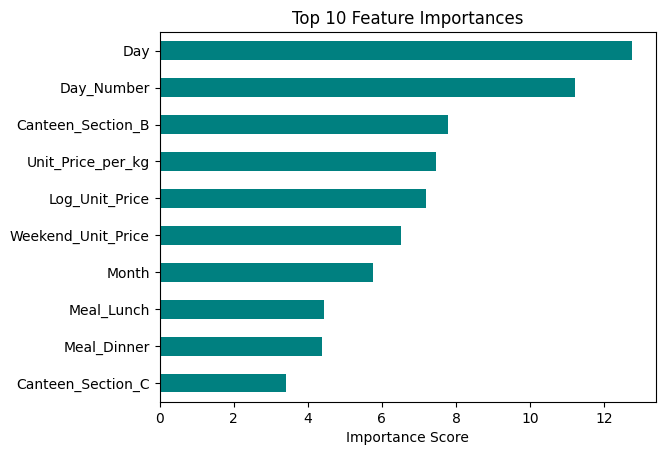

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# Inspect feature importances from CatBoost
importances = pd.Series(cat_model.get_feature_importance(), index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

##confusion matrix

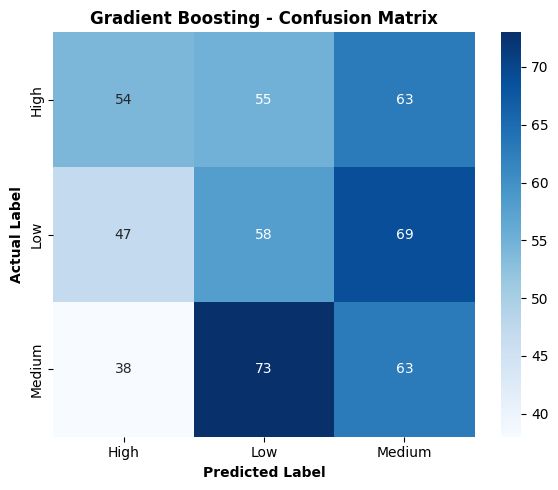

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate predictions
y_pred_gb = gb_model.predict(X_test)

# 2. Extract unique class labels in order
labels = sorted(y_test.unique())

# 3. Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb, labels=labels)

# 4. Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label", fontsize=10, fontweight="bold")
plt.ylabel("Actual Label", fontsize=10, fontweight="bold")
plt.title("Gradient Boosting - Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()

plt.show()

##cross-validation score

In [134]:
from sklearn.model_selection import cross_val_score

# Run 5-Fold Stratified Cross-Validation
cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# Output detailed summary
print("=== Gradient Boosting Cross-Validation ===")
print("Fold Scores: ", [round(score, 4) for score in cv_scores])
print(f"Average CV F1: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

=== Gradient Boosting Cross-Validation ===
Fold Scores:  [np.float64(0.3523), np.float64(0.3136), np.float64(0.3852), np.float64(0.3392), np.float64(0.3337)]
Average CV F1: 0.3448
Std Deviation: 0.0237


In [135]:
!pip install shap

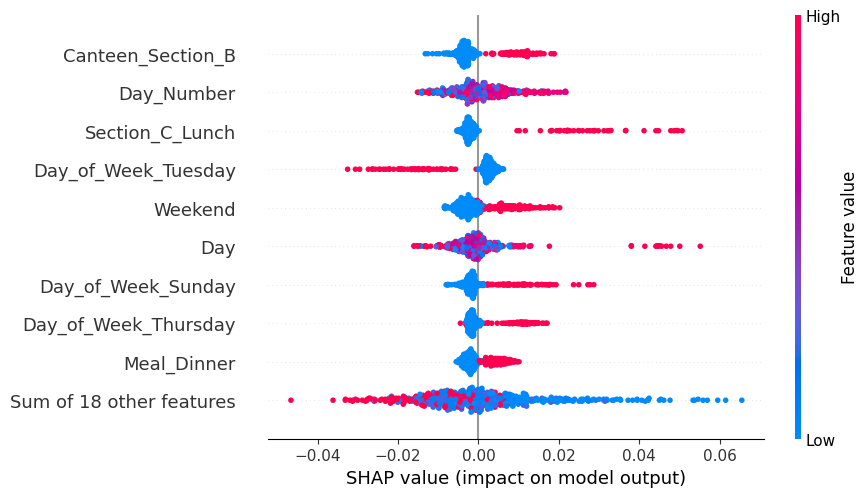

In [138]:
import shap

# 1. Create explainer
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values[:, :, 0], max_display=10)

Dot Plot (Single Class):

Red dots = High value of that feature.

Blue dots = Low value of that feature.

Right side (positive SHAP): Pushes the model toward predicting that specific class.

Left side (negative SHAP): Pushes the model away from predicting that class.

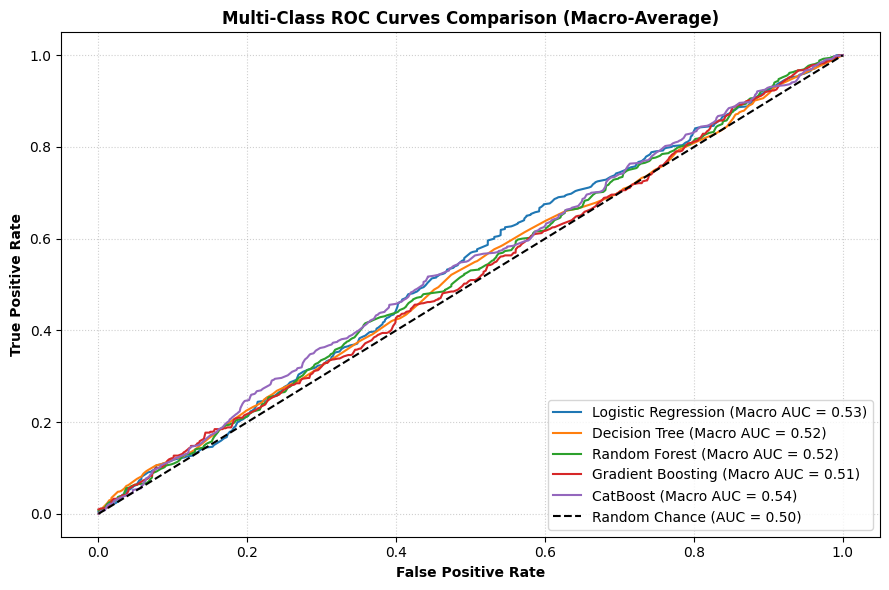

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize y_test for One-vs-Rest ROC (e.g., Low, Medium, High)
classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# 2. Define models with their specific test sets
models = [
    ("Logistic Regression", lr_model, X_test_scaled),
    ("Decision Tree", dt_model, X_test),
    ("Random Forest", rf_model, X_test),
    ("Gradient Boosting", gb_model, X_test),
    ("CatBoost", cat_model, X_test)
]

plt.figure(figsize=(9, 6))

# 3. Calculate macro-average ROC Curve for each model
for name, model, test_data in models:
    # Get probability predictions
    y_score = model.predict_proba(test_data)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

    # Compute macro-average ROC curve
    all_fpr = sorted(list(set(sum([list(fpr[i]) for i in range(n_classes)], []))))
    mean_tpr = sum([plt.np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)]) / n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot model curve
    plt.plot(all_fpr, mean_tpr, label=f"{name} (Macro AUC = {macro_auc:.2f})")

# 4. Format Chart
plt.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=10, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=10, fontweight="bold")
plt.title("Multi-Class ROC Curves Comparison (Macro-Average)", fontsize=12, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

Model Saving

In [140]:
import joblib

# 1. Save the best-performing model (CatBoost)
joblib.dump(cat_model, "food_waste_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


Model Comparison Table


In [145]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test),
    "CatBoost": (cat_model, X_test)
}

results = []

for name, (model, test_data) in models.items():
    preds = model.predict(test_data)

    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

    try:
        probs = model.predict_proba(test_data)
        auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")
    except Exception:
        auc = None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

# HERE is where 'comparison' gets defined:
comparison = pd.DataFrame(results)

In [146]:
comparison.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,CatBoost,0.373077,0.373246,0.373077,0.370777,0.533909
0,Logistic Regression,0.351923,0.350699,0.351923,0.350907,0.532489
2,Random Forest,0.346154,0.345397,0.346154,0.344922,0.522796
3,Gradient Boosting,0.336538,0.340949,0.336538,0.336945,0.514092
1,Decision Tree,0.344231,0.344158,0.344231,0.336495,0.521009


In [147]:
# ==========================================
# STEP 26 : Handle Class Imbalance with SMOTE
# ==========================================
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Ensure df exists; load fallback if necessary
file_path = "/content/food_waste_dataset.csv"  # Update with your filename if needed

if 'df' not in locals():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
    else:
        raise FileNotFoundError(f"Could not find {file_path}. Please check file path.")

# 2. Define Features (X) and Target (y)
# Drop leakage columns and target column from X
drop_cols = ["Waste_Level", "Waste_Weight_kg", "Cost_Loss"]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df["Waste_Level"]

# Convert categorical features in X to numerical dummy variables if not done yet
X = pd.get_dummies(X, drop_first=True)

# 3. Stratified Train-Test Split (Preserves class proportions before SMOTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Feature Scaling (Identify numeric columns dynamically)
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 5. Apply SMOTE to rebalance classes ONLY on the Training set
smote = SMOTE(random_state=42)

# Unscaled SMOTE (for tree models like Random Forest, CatBoost, XGBoost)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scaled SMOTE (for linear/distance models like Logistic Regression)
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

# 6. Print class distributions
print("=== SMOTE Resampling Results ===")
print("Before SMOTE (y_train):", y_train.value_counts().to_dict())
print("After SMOTE  (y_train_sm):", pd.Series(y_train_sm).value_counts().to_dict())

=== SMOTE Resampling Results ===
Before SMOTE (y_train): {'Medium': 698, 'Low': 695, 'High': 687}
After SMOTE  (y_train_sm): {'Low': 698, 'Medium': 698, 'High': 698}


In [148]:
# ==========================================
# STEP 27 : Multi-Class Threshold Tuning
# ==========================================
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier

def optimize_multiclass_thresholds(y_true, probas, classes):
    """
    Sweeps probability multipliers across classes to maximize overall macro F1-score.
    """
    best_weights = [1.0] * len(classes)
    best_f1 = -1.0

    # Test weight grids for each class
    grid = np.arange(0.5, 2.0, 0.25)

    for w0 in grid:      # Class 0 Weight
        for w1 in grid:  # Class 1 Weight
            for w2 in grid: # Class 2 Weight
                weights = np.array([w0, w1, w2])

                # Apply weights to probabilities and take argmax
                weighted_probas = probas * weights
                preds_idx = np.argmax(weighted_probas, axis=1)
                preds = [classes[i] for i in preds_idx]

                f1 = f1_score(y_true, preds, average="macro")

                if f1 > best_f1:
                    best_f1 = f1
                    best_weights = weights

    return best_weights, best_f1

In [149]:
# ==========================================
# STEP 28 : Train & Apply Tuned Thresholds
# ==========================================

# 1. Initialize and train Random Forest on SMOTE data
best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)
best_rf.fit(X_train_sm, y_train_sm)

# 2. Get predicted probabilities on unscaled test set
rf_probas = best_rf.predict_proba(X_test)
classes = best_rf.classes_

# 3. Find optimal class weights
best_weights, best_f1 = optimize_multiclass_thresholds(y_test, rf_probas, classes)

print("=== Threshold Optimization Results ===")
for cls, weight in zip(classes, best_weights):
    print(f"Optimal Weight for '{cls}': {weight:.2f}")
print(f"Optimized Macro F1-Score: {best_f1:.4f}\n")

# 4. Apply tuned threshold weights to derive custom predictions
weighted_probas = rf_probas * best_weights
custom_preds_idx = np.argmax(weighted_probas, axis=1)
custom_preds = [classes[i] for i in custom_preds_idx]

# 5. Output Classification Report
print("Classification Report with Optimized Thresholds:")
print(classification_report(y_test, custom_preds))

=== Threshold Optimization Results ===
Optimal Weight for 'High': 0.50
Optimal Weight for 'Low': 0.50
Optimal Weight for 'Medium': 0.50
Optimized Macro F1-Score: 0.3665

Classification Report with Optimized Thresholds:
              precision    recall  f1-score   support

        High       0.38      0.39      0.38       172
         Low       0.37      0.40      0.38       174
      Medium       0.35      0.32      0.33       174

    accuracy                           0.37       520
   macro avg       0.37      0.37      0.37       520
weighted avg       0.37      0.37      0.37       520



In [150]:
# ==========================================
# STEP 28 : Final Comparative Evaluation
# ==========================================
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def full_eval_multiclass(model, X_test, y_test, model_name, weights=None):
    # 1. Get probability predictions
    probas = model.predict_proba(X_test)
    classes = model.classes_

    # 2. Apply threshold weights if provided, else standard argmax
    if weights is not None:
        weighted_probas = probas * weights
        preds_idx = np.argmax(weighted_probas, axis=1)
    else:
        preds_idx = np.argmax(probas, axis=1)

    preds = [classes[i] for i in preds_idx]

    # 3. Calculate Overall Multi-class Metrics
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec  = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1   = f1_score(y_test, preds, average="weighted", zero_division=0)

    try:
        roc = roc_auc_score(y_test, probas, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan

    cm = confusion_matrix(y_test, preds, labels=classes)

    print("=" * 60)
    print(f"Model: {model_name}")
    print("=" * 60)
    print(f"Accuracy: {acc:.3f} | Weighted F1: {f1:.3f} | Macro ROC-AUC: {roc:.3f}")
    print(f"Precision: {prec:.3f} | Recall: {rec:.3f}")
    print(f"Confusion Matrix ({classes}):\n{cm}\n")

    return {
        "Model": model_name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1_Score": round(f1, 3),
        "Macro_ROC_AUC": round(roc, 3)
    }

final_results = []

# 1. Logistic Regression + Scaled SMOTE
lr_sm = LogisticRegression(random_state=42)
lr_sm.fit(X_train_scaled_sm, y_train_scaled_sm)
final_results.append(full_eval_multiclass(lr_sm, X_test_scaled, y_test, "Logistic Regression + SMOTE"))

# 2. Decision Tree + SMOTE
dt_sm = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_sm.fit(X_train_sm, y_train_sm)
final_results.append(full_eval_multiclass(dt_sm, X_test, y_test, "Decision Tree + SMOTE"))

# 3. Random Forest + SMOTE + Tuned Thresholds
rf_sm = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)
# Retrieve weights from Step 27 if available, otherwise default to None
weights_rf = best_weights if 'best_weights' in locals() else None
final_results.append(full_eval_multiclass(rf_sm, X_test, y_test, "Random Forest + SMOTE", weights_rf))

# 4. Gradient Boosting + SMOTE
gb_sm = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_sm.fit(X_train_sm, y_train_sm)
final_results.append(full_eval_multiclass(gb_sm, X_test, y_test, "Gradient Boosting + SMOTE"))

# 5. CatBoost + SMOTE
cat_sm = CatBoostClassifier(verbose=0, random_state=42)
cat_sm.fit(X_train_sm, y_train_sm)
final_results.append(full_eval_multiclass(cat_sm, X_test, y_test, "CatBoost + SMOTE"))

# Display summary table sorted by Weighted F1
comparison_df = pd.DataFrame(final_results)
print("=== FINAL COMPARATIVE EVALUATION SUMMARY ===")
display(comparison_df.sort_values(by="F1_Score", ascending=False).reset_index(drop=True))

Model: Logistic Regression + SMOTE
Accuracy: 0.362 | Weighted F1: 0.360 | Macro ROC-AUC: 0.533
Precision: 0.361 | Recall: 0.362
Confusion Matrix (['High' 'Low' 'Medium']):
[[69 52 51]
 [61 69 44]
 [66 58 50]]

Model: Decision Tree + SMOTE
Accuracy: 0.344 | Weighted F1: 0.296 | Macro ROC-AUC: 0.514
Precision: 0.354 | Recall: 0.344
Confusion Matrix (['High' 'Low' 'Medium']):
[[ 34  16 122]
 [ 34  20 120]
 [ 33  16 125]]

Model: Random Forest + SMOTE
Accuracy: 0.367 | Weighted F1: 0.367 | Macro ROC-AUC: 0.530
Precision: 0.367 | Recall: 0.367
Confusion Matrix (['High' 'Low' 'Medium']):
[[67 52 53]
 [54 67 53]
 [51 66 57]]

Model: Gradient Boosting + SMOTE
Accuracy: 0.362 | Weighted F1: 0.360 | Macro ROC-AUC: 0.516
Precision: 0.362 | Recall: 0.362
Confusion Matrix (['High' 'Low' 'Medium']):
[[69 60 43]
 [55 67 52]
 [51 71 52]]

Model: CatBoost + SMOTE
Accuracy: 0.342 | Weighted F1: 0.342 | Macro ROC-AUC: 0.504
Precision: 0.342 | Recall: 0.342
Confusion Matrix (['High' 'Low' 'Medium']):
[[57

,Model,Accuracy,Precision,Recall,F1_Score,Macro_ROC_AUC
0,Random Forest + SMOTE,0.367,0.367,0.367,0.367,0.530
1,Logistic Regression + SMOTE,0.362,0.361,0.362,0.360,0.533
2,Gradient Boosting + SMOTE,0.362,0.362,0.362,0.360,0.516
3,CatBoost + SMOTE,0.342,0.342,0.342,0.342,0.504
4,Decision Tree + SMOTE,0.344,0.354,0.344,0.296,0.514


=== FINAL MODEL PERFORMANCE RANKING ===


,Model,Accuracy,Precision,Recall,F1_Score,Macro_ROC_AUC
0,Random Forest + SMOTE,0.367,0.367,0.367,0.367,0.530
1,Logistic Regression + SMOTE,0.362,0.361,0.362,0.360,0.533
2,Gradient Boosting + SMOTE,0.362,0.362,0.362,0.360,0.516
3,CatBoost + SMOTE,0.342,0.342,0.342,0.342,0.504
4,Decision Tree + SMOTE,0.344,0.354,0.344,0.296,0.514


/tmp/ipykernel_5548/3464140371.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


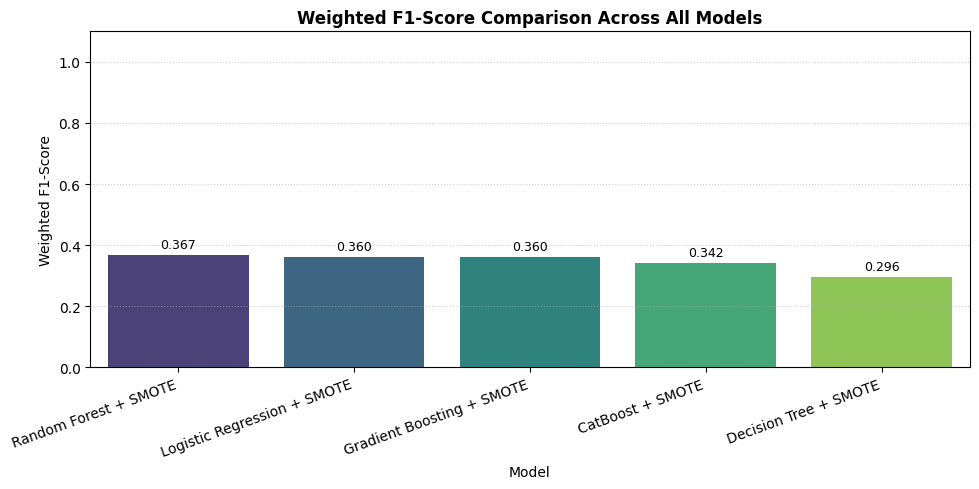

/tmp/ipykernel_5548/3464140371.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


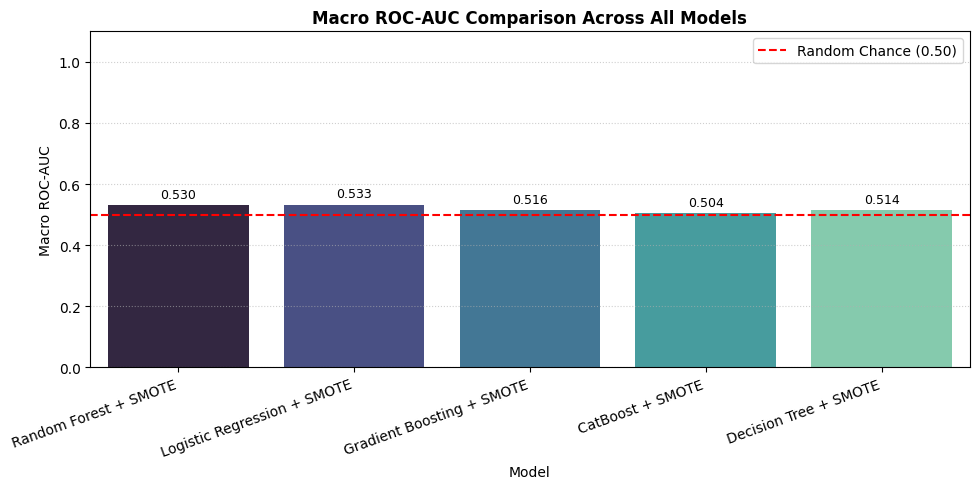

In [151]:
# ==========================================
# STEP 29 : Compare All Configurations
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Step 28 results into DataFrame
final_comparison = pd.DataFrame(final_results)

# 2. Rank by overall F1_Score (weighted performance across Low, Medium, High)
final_comparison.sort_values("F1_Score", ascending=False, inplace=True)

print("=== FINAL MODEL PERFORMANCE RANKING ===")
display(final_comparison.reset_index(drop=True))

# 3. Plot 1: F1 Score Comparison
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x="Model",
    y="F1_Score",
    data=final_comparison,
    palette="viridis"
)

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9, xytext=(0, 3),
        textcoords='offset points'
    )

plt.title("Weighted F1-Score Comparison Across All Models", fontsize=12, fontweight="bold")
plt.ylabel("Weighted F1-Score", fontsize=10)
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha="right")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Plot 2: Macro ROC-AUC Comparison
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(
    x="Model",
    y="Macro_ROC_AUC",
    data=final_comparison,
    palette="mako"
)

for p in ax2.patches:
    ax2.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9, xytext=(0, 3),
        textcoords='offset points'
    )

plt.title("Macro ROC-AUC Comparison Across All Models", fontsize=12, fontweight="bold")
plt.ylabel("Macro ROC-AUC", fontsize=10)
plt.axhline(0.50, color="red", linestyle="--", label="Random Chance (0.50)")
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [152]:
# ==========================================
# STEP 30 : Select and Save the Final Model
# ==========================================
import joblib
import pandas as pd

# 1. Identify top-performing model configuration from Step 29
best_config = final_comparison.iloc[0]
best_model_name = best_config["Model"]

print(f"Selected Final Model: {best_model_name}")
print(f"Top F1-Score: {best_config['F1_Score']:.4f} | Top Macro ROC-AUC: {best_config['Macro_ROC_AUC']:.4f}\n")

# 2. Map name to actual trained model object
model_lookup = {
    "Logistic Regression + SMOTE": lr_sm,
    "Decision Tree + SMOTE": dt_sm,
    "Random Forest + SMOTE": rf_sm,
    "Gradient Boosting + SMOTE": gb_sm,
    "CatBoost + SMOTE": cat_sm
}

final_model = model_lookup[best_model_name]

# 3. Retrieve optimal class weights if available
final_weights = best_weights if 'best_weights' in locals() else None

# 4. Save model artifact bundle
model_bundle = {
    "model": final_model,
    "class_weights": final_weights,
    "features": list(X.columns),
    "target_classes": list(final_model.classes_)
}

joblib.dump(model_bundle, "final_food_waste_model.pkl")
print("Successfully saved 'final_food_waste_model.pkl'!")

Selected Final Model: Random Forest + SMOTE
Top F1-Score: 0.3670 | Top Macro ROC-AUC: 0.5300

Successfully saved 'final_food_waste_model.pkl'!


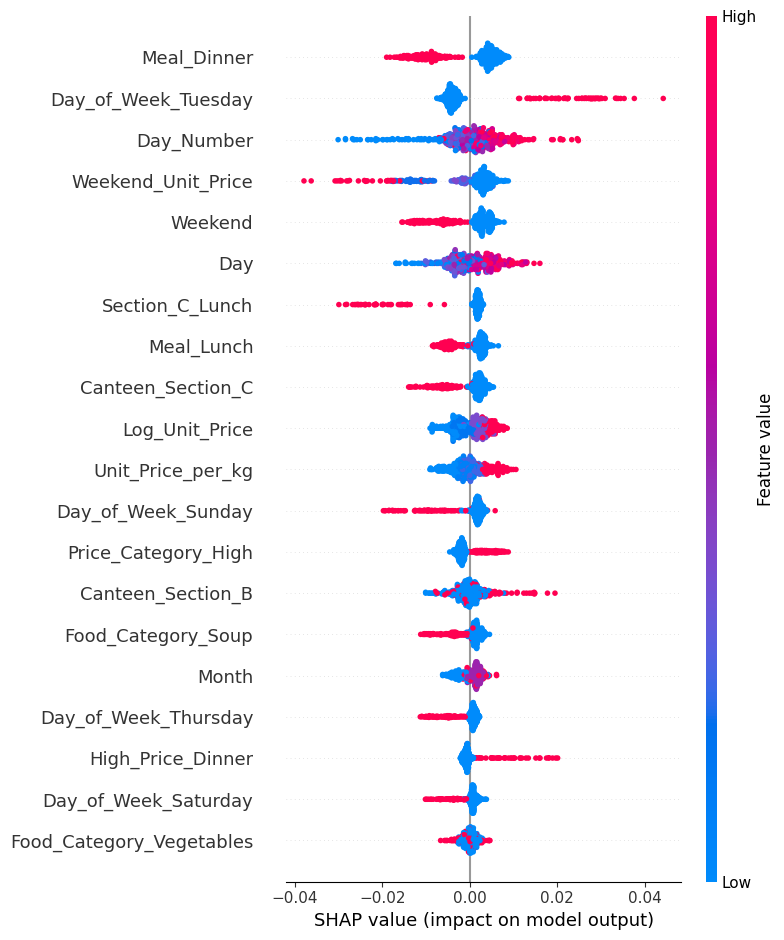

,Feature,MeanAbsSHAP
5,Meal_Dinner,0.006697
17,Day_of_Week_Tuesday,0.006462
4,Day_Number,0.005222
24,Weekend_Unit_Price,0.005135
3,Weekend,0.004597
1,Day,0.004204
25,Section_C_Lunch,0.003318
6,Meal_Lunch,0.003251
11,Canteen_Section_C,0.003221
22,Log_Unit_Price,0.003204


In [153]:
# ==========================================
# STEP 31 : SHAP Interpretation of the Final Model
# ==========================================

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]           # class 1 ("used") contributions
elif len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_test)

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "MeanAbsSHAP": np.abs(sv).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

display(shap_importance.head(10))